# Soccer Data Visualization and Analysis

This notebook analyzes a player performance data using visualizations and statistical metrics. The focus is on understanding shot patterns, expected goals (xG), and overall player performance.

In [1]:
#importa libraries
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
import matplotlib.font_manager as font_manager

In [2]:
df = pd.read_csv('salah_understat_2024.csv')

In [3]:
df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,584693,46,BlockedShot,0.874,0.338,0.040268,Mohamed Salah,a,1250,FromCorner,2024,LeftFoot,26603,Ipswich,Liverpool,0,2,2024-08-17 11:30:00,Luis Díaz,Pass
1,584700,64,Goal,0.937,0.449,0.571324,Mohamed Salah,a,1250,OpenPlay,2024,LeftFoot,26603,Ipswich,Liverpool,0,2,2024-08-17 11:30:00,NaN,NaN
2,584702,70,SavedShot,0.837,0.563,0.403200,Mohamed Salah,a,1250,OpenPlay,2024,LeftFoot,26603,Ipswich,Liverpool,0,2,2024-08-17 11:30:00,Dominik Szoboszlai,Throughball
3,584707,93,SavedShot,0.931,0.347,0.081943,Mohamed Salah,a,1250,OpenPlay,2024,LeftFoot,26603,Ipswich,Liverpool,0,2,2024-08-17 11:30:00,NaN,NaN
4,586849,20,MissedShots,0.882,0.314,0.064414,Mohamed Salah,h,1250,OpenPlay,2024,LeftFoot,26621,Liverpool,Brentford,2,0,2024-08-25 15:30:00,Trent Alexander-Arnold,Pass


### Preprocessing
- Coordinates have been scaled to match the soccer field dimensions.
- Key statistics such as total shots, goals, and average xG are calculated.

In [4]:
df['X'] = df['X'] * 100
df['Y'] = df['Y'] * 100

In [5]:
total_shots = df.shape[0]
total_goals = df[df['result'] == 'Goal'].shape[0]
total_xG = df['xG'].sum()
xG_per_shot = total_xG / total_shots
points_average_distance = df['X'].mean()
actual_average_distance = 120 - (df['X']*1.2).mean()

In [6]:
background_color = '#0C0D0E'

In [7]:
font_path = '/Users/alejo/OneDrive/Documentos/futlife/fonts/Arvo-Regular.ttf'
font_props = font_manager.FontProperties(fname=font_path)

## Visualization

This notebook visualizes:
- Shot locations on a soccer field.
- Quality of the shot taken. 
- Heatmaps showing areas of frequent activity.
- Annotated plots to highlight key performance metrics.

Text(0.63, 0, '0.22')

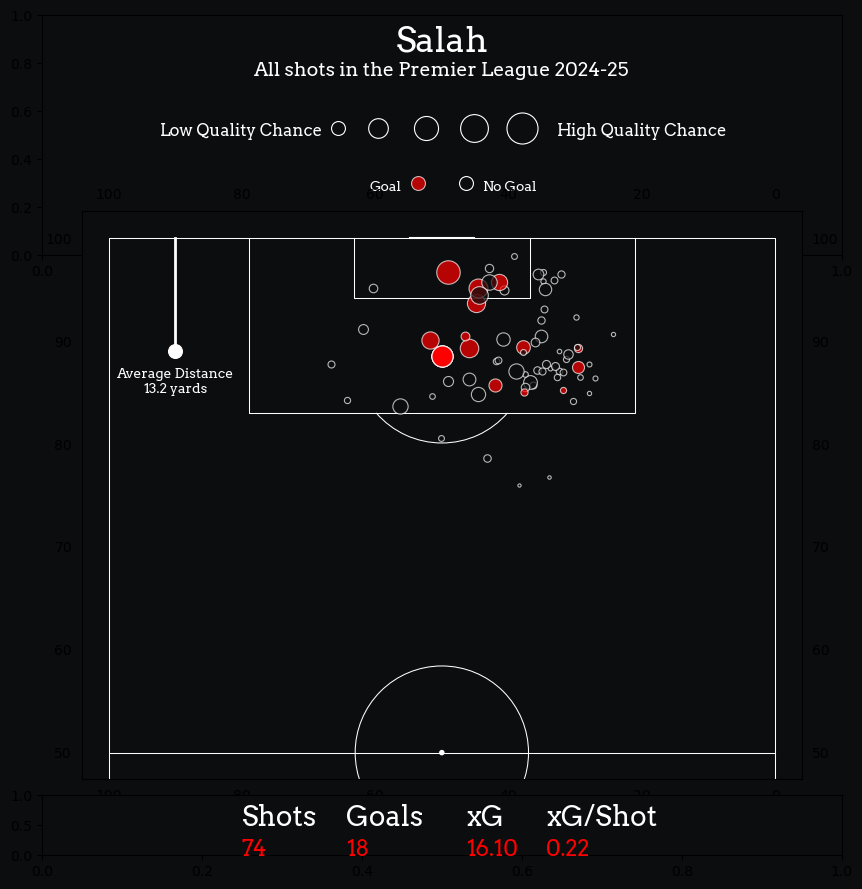

In [9]:
fig = plt.figure(figsize=(8,12))
fig.patch.set_facecolor(background_color)

#Create the first section of the image
ax1 = fig.add_axes([0, 0.7, 1, 0.2])
ax1.set_facecolor(background_color)
ax1.set_xlim(0,1)
ax1.set_ylim(0,1)

# Create text for player name
ax1.text(
    x=0.5,
    y=0.85,
    s='Salah',
    fontsize=25,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)
#Create subtitle fot the displayed data
ax1.text(
    x=0.5,
    y=0.75,
    s='All shots in the Premier League 2024-25',
    fontsize=14,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)
#Low quality text
ax1.text(
    x=0.25,
    y=0.5,
    s='Low Quality Chance',
    fontsize=12,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)
#Create cricles of the quality of chances
ax1.scatter(
    x=0.37,
    y=0.53,
    s=100,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8
)

ax1.scatter(
    x=0.42,
    y=0.53,
    s=200,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8
)

ax1.scatter(
    x=0.48,
    y=0.53,
    s=300,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8
)

ax1.scatter(
    x=0.54,
    y=0.53,
    s=400,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8
)

ax1.scatter(
    x=0.6,
    y=0.53,
    s=500,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8
)

#Create High quality of chances text
ax1.text(
    x=0.75,
    y=0.5,
    s='High Quality Chance',
    fontsize=12,
    fontproperties=font_props,
    fontweight='bold',
    color='white',
    ha='center'
)

#Create the goal visual
ax1.text(
    x=0.45,
    y=0.27,
    s=f'Goal',
    fontsize=10,
    fontproperties=font_props,
    color='white',
    ha='right'
)

ax1.scatter(
    x=0.47,
    y=0.3,
    s=100,
    color = 'red',
    edgecolor = 'white',
    linewidth= 0.8,
    alpha=0.7
)
#Create the no goal visual
ax1.text(
    x=0.55,
    y=0.27,
    s=f'No Goal',
    fontsize=10,
    fontproperties=font_props,
    color='white',
    ha='left'
)

ax1.scatter(
    x=0.53,
    y=0.3,
    s=100,
    color = background_color,
    edgecolor = 'white',
    linewidth= 0.8,
)
    

#Creates the second section of the image
ax2 = fig.add_axes([0.05, 0.25, 0.9, 0.5])
ax2.set_facecolor(background_color)

# Create the pitch
pitch = VerticalPitch(
    pitch_type = 'opta',
    half=True,
    pitch_color = background_color,
    line_color='white',
    linewidth = 0.75,
    axis = True,
    label = True
)

#Draw the pitch
pitch.draw(ax=ax2)

#create average distance
ax2.scatter(
    x = 90,
    y = points_average_distance,
    s = 100,
    color = 'white',
    linewidth = 0.8,
)

#create a line until the point of average distance
ax2.plot(
    [90, 90],
    [100, points_average_distance],
    color = 'white',
    linewidth = 2
)
# text that shows the distance
ax2.text(
    x = 90,
    y = points_average_distance - 4,
    s = f'Average Distance\n{actual_average_distance:.1f} yards',
    fontsize = 10,
    fontproperties = font_props,
    color ='white',
    ha = 'center'
)

# plot the actual shots

for x in df.to_dict(orient='records'):
    pitch.scatter(
        x['X'],
        x['Y'],
        s = 300 * x['xG'],
        color = 'red' if x['result'] == 'Goal' else background_color,
        ax = ax2,
        alpha = 0.7,
        linewidth = 0.8,
        edgecolor = 'white'
    )



#Create the third section of the image
ax3 = fig.add_axes([0, 0.2, 1, 0.05])
ax3.set_facecolor(background_color)
#Number of shots
ax3.text(
    x = 0.25,
    y = 0.5,
    s = 'Shots',
    fontsize = 20,
    fontproperties = font_props,
    fontweight = 'bold',
    color = 'white',
)
ax3.text(
    x = 0.25,
    y = 0,
    s = f'{total_shots}',
    fontsize = 16,
    fontproperties = font_props,
    color = 'red',
    ha = 'left'
)

#Number of goals
ax3.text(
    x = 0.38,
    y = 0.5,
    s = 'Goals',
    fontsize = 20,
    fontproperties = font_props,
    fontweight = 'bold',
    color = 'white',
)
ax3.text(
    x = 0.38,
    y = 0,
    s = f'{total_goals}',
    fontsize = 16,
    fontproperties = font_props,
    color = 'red',
    ha = 'left'
)

#Number of goals
ax3.text(
    x = 0.53,
    y = 0.5,
    s = 'xG',
    fontsize = 20,
    fontproperties = font_props,
    fontweight = 'bold',
    color = 'white',
)
ax3.text(
    x = 0.53,
    y = 0,
    s = f'{total_xG:.2f}',
    fontsize = 16,
    fontproperties = font_props,
    color = 'red',
    ha = 'left'
)

#Number of goals
ax3.text(
    x = 0.63,
    y = 0.5,
    s = 'xG/Shot',
    fontsize = 20,
    fontproperties = font_props,
    fontweight = 'bold',
    color = 'white',
)
ax3.text(
    x = 0.63,
    y = 0,
    s = f'{xG_per_shot:.2f}',
    fontsize = 16,
    fontproperties = font_props,
    color = 'red',
    ha = 'left'
)